# Stage 1: Detection Pipeline

This notebook demonstrates the detection stage of the small object tracking pipeline, covering:
1. Frame preprocessing (grayscale, blur)
2. Background subtraction
3. Morphological operations
4. Connected component analysis
5. Centroid extraction

Based on the project proposal's detection module implementation.


In [3]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
import glob
import sys
sys.path.append('..')

from detector import ObjectDetector

plt.rcParams['figure.figsize'] = (15, 10)


## Load Video Frames


In [4]:
video_name = 'bees_short'
frame_pattern = f"../data/images/{video_name}/images/*.jpg"
frame_files = sorted(glob.glob(frame_pattern))

print(f"Video: {video_name}")
print(f"Frames: {len(frame_files)}")

frames = [cv2.imread(f) for f in frame_files[:50]]
print(f"Loaded {len(frames)} frames, Shape: {frames[0].shape}")


Video: bees_short
Frames: 840
Loaded 50 frames, Shape: (1156, 2052, 3)


## Step 1: Preprocessing

Convert to grayscale and apply Gaussian blur to reduce noise.


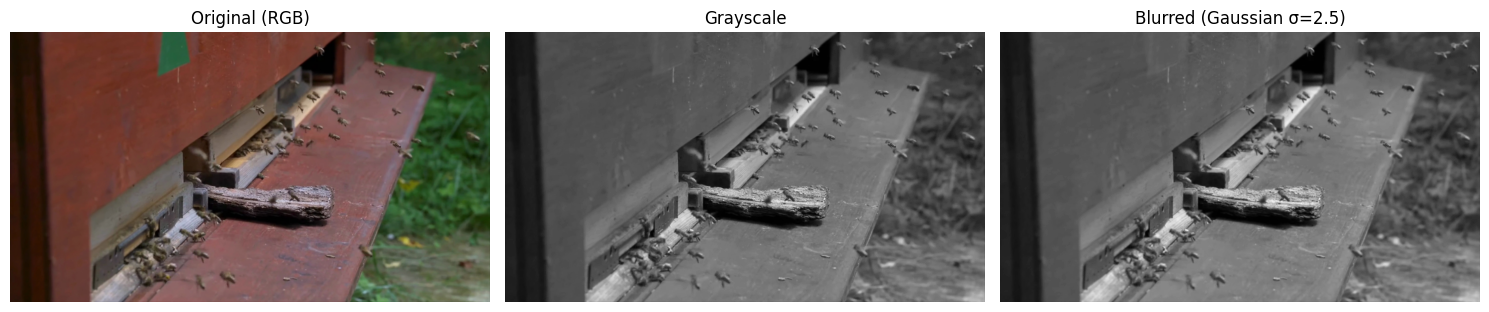

In [ ]:
sample_frame = frames[20]

gray = cv2.cvtColor(sample_frame, cv2.COLOR_BGR2GRAY)

blurred = cv2.GaussianBlur(gray, (5, 5), 0)

fig, axes = plt.subplots(1, 3, figsize=(15, 5))
axes[0].imshow(cv2.cvtColor(sample_frame, cv2.COLOR_BGR2RGB))
axes[0].set_title('Original (RGB)')
axes[0].axis('off')

axes[1].imshow(gray, cmap='gray')
axes[1].set_title('Grayscale')
axes[1].axis('off')

axes[2].imshow(blurred, cmap='gray')
axes[2].set_title('Blurred (Gaussian σ=2.5)')
axes[2].axis('off')

plt.tight_layout()
plt.show()


## Step 2: Background Subtraction

Use KNN background subtractor to learn static background and detect moving objects.


Background model learned from 30 frames


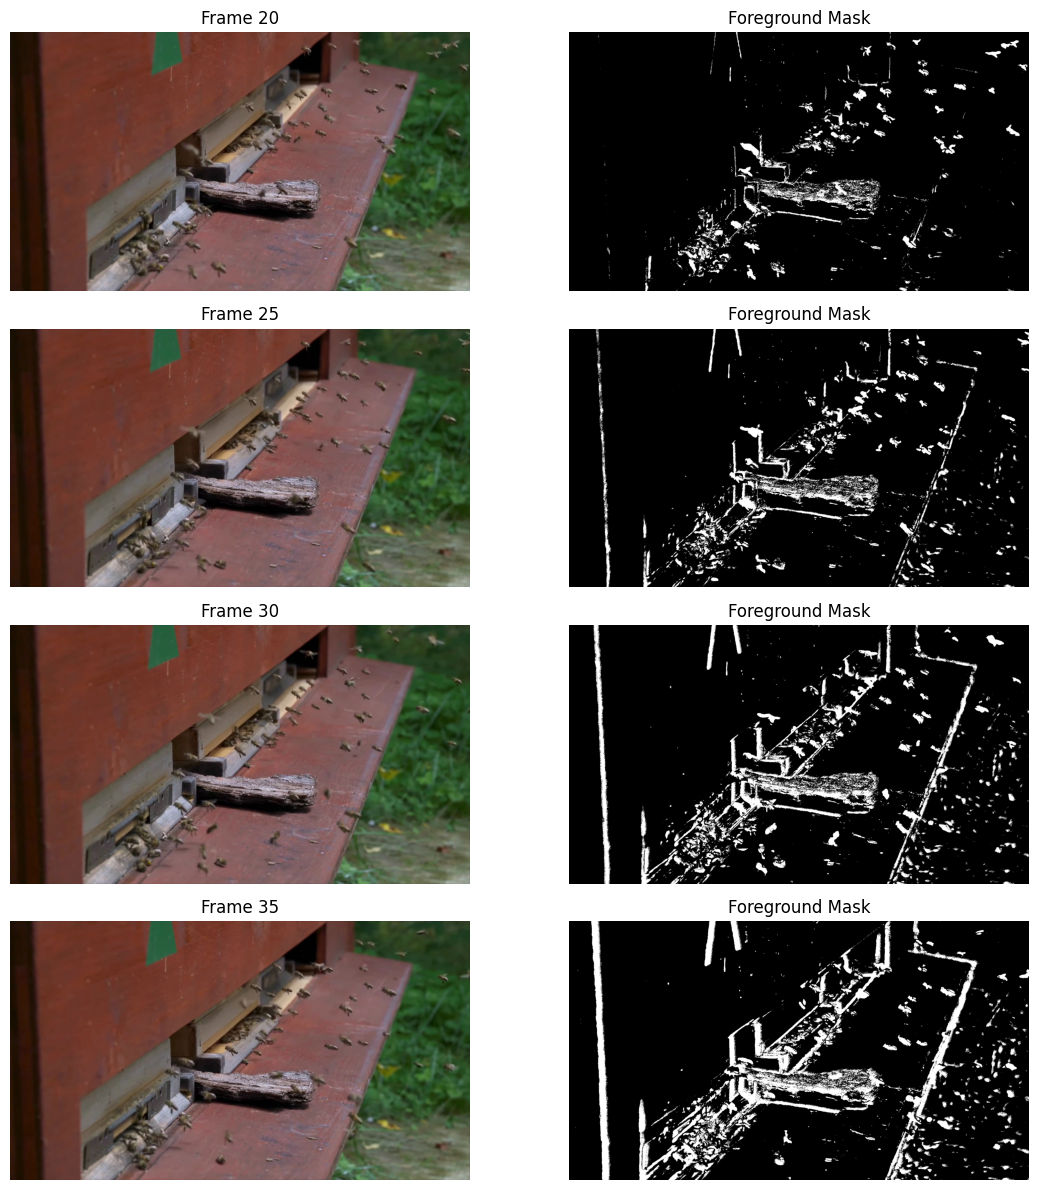

In [6]:
back_sub = cv2.createBackgroundSubtractorKNN(
    history=500,
    dist2Threshold=800.0,
    detectShadows=False
)

for i, frame in enumerate(frames[:30]):
    back_sub.apply(frame)
    
print(f"Background model learned from {i+1} frames")

test_frames = [20, 25, 30, 35]
fg_masks = []

fig, axes = plt.subplots(len(test_frames), 2, figsize=(12, 12))

for idx, frame_num in enumerate(test_frames):
    frame = frames[frame_num]
    fg_mask = back_sub.apply(frame)
    fg_masks.append(fg_mask)
    
    axes[idx, 0].imshow(cv2.cvtColor(frame, cv2.COLOR_BGR2RGB))
    axes[idx, 0].set_title(f'Frame {frame_num}')
    axes[idx, 0].axis('off')
    
    axes[idx, 1].imshow(fg_mask, cmap='gray')
    axes[idx, 1].set_title('Foreground Mask')
    axes[idx, 1].axis('off')

plt.tight_layout()
plt.show()


## Step 3: Morphological Operations

Apply erosion and dilation to remove noise and reconnect separated parts.


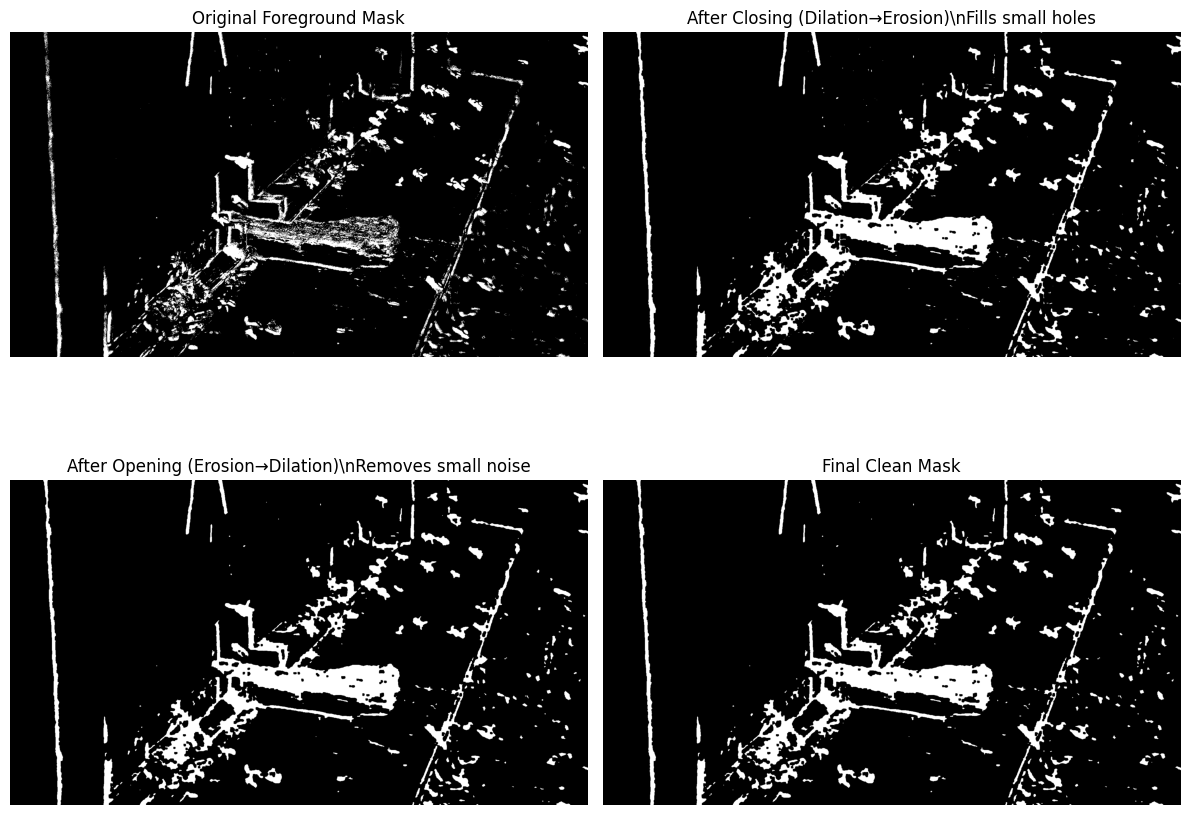

Noise pixels removed: -70644


In [ ]:
kernel_erode = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (3, 3))
kernel_dilate = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (8, 8))

fg_mask = fg_masks[1]

closed = cv2.morphologyEx(fg_mask, cv2.MORPH_CLOSE, kernel_dilate)
opened = cv2.morphologyEx(closed, cv2.MORPH_OPEN, kernel_erode)

fig, axes = plt.subplots(2, 2, figsize=(12, 10))

axes[0, 0].imshow(fg_mask, cmap='gray')
axes[0, 0].set_title('Original Foreground Mask')
axes[0, 0].axis('off')

axes[0, 1].imshow(closed, cmap='gray')
axes[0, 1].set_title('After Closing (Dilation→Erosion)\nFills small holes')
axes[0, 1].axis('off')

axes[1, 0].imshow(opened, cmap='gray')
axes[1, 0].set_title('After Opening (Erosion→Dilation)\nRemoves small noise')
axes[1, 0].axis('off')

axes[1, 1].imshow(opened, cmap='gray')
axes[1, 1].set_title('Final Clean Mask')
axes[1, 1].axis('off')

plt.tight_layout()
plt.show()

print(f"Noise pixels removed: {np.sum(fg_mask > 0) - np.sum(opened > 0)}")


## Step 4: Connected Components & Centroid Extraction

Find contours and compute centroids for each blob.


Found 289 contours


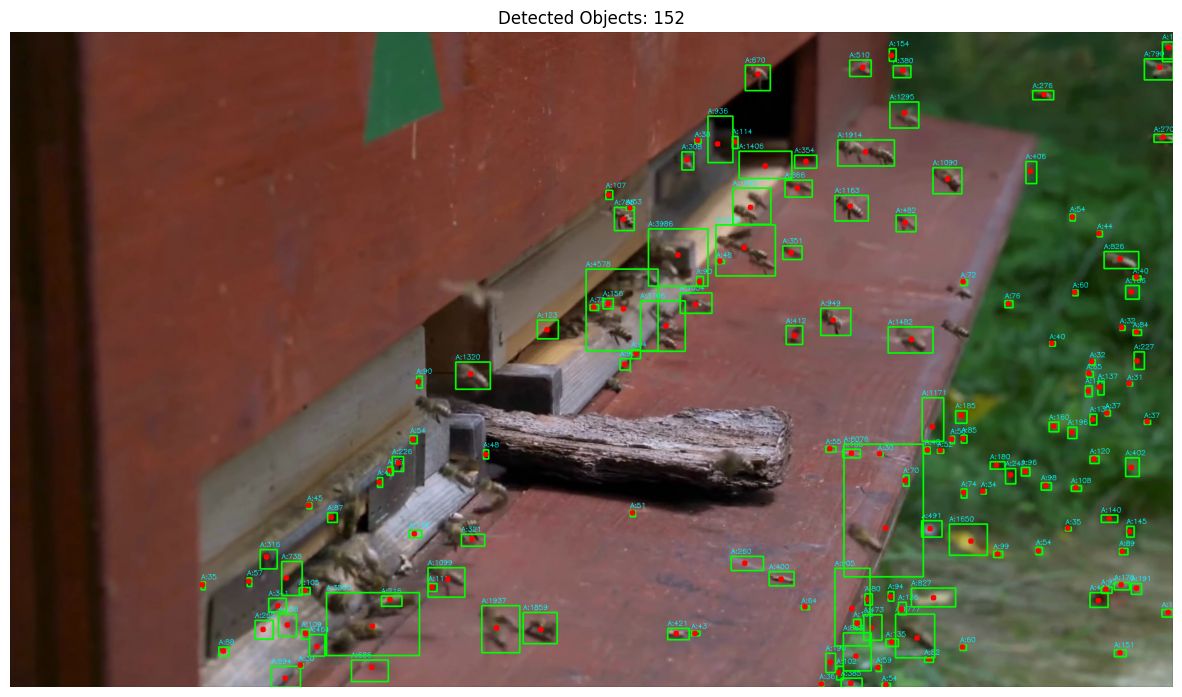

\nDetections: 152
  0: centroid=(1545, 1152), size=15x7
  1: centroid=(1431, 1150), size=7x10
  2: centroid=(1483, 1149), size=37x16
  3: centroid=(1461, 1130), size=12x24
  4: centroid=(485, 1140), size=51x37


In [ ]:
# Find contours
contours, _ = cv2.findContours(opened, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)

print(f"Found {len(contours)} contours")

detections = []
vis_frame = frames[25].copy()

for cnt in contours:
    area = cv2.contourArea(cnt)
    
    if not (30 < area < 100000):
        continue
    
    x, y, w, h = cv2.boundingRect(cnt)
    aspect_ratio = float(w) / h if h > 0 else 0
    
    # Filter by aspect ratio
    if not (0.4 < aspect_ratio < 2.5):
        continue
    
    # Compute centroid using image moments
    M = cv2.moments(cnt)
    if M["m00"] != 0:
        cX = int(M["m10"] / M["m00"])
        cY = int(M["m01"] / M["m00"])
        
        detections.append([cX, cY, w, h])
        
        # Draw on visualization
        cv2.rectangle(vis_frame, (x, y), (x+w, y+h), (0, 255, 0), 2)
        cv2.circle(vis_frame, (cX, cY), 5, (0, 0, 255), -1)
        cv2.putText(vis_frame, f"A:{area:.0f}", (x, y-5),
                   cv2.FONT_HERSHEY_SIMPLEX, 0.4, (255, 255, 0), 1)

plt.figure(figsize=(15, 10))
plt.imshow(cv2.cvtColor(vis_frame, cv2.COLOR_BGR2RGB))
plt.title(f'Detected Objects: {len(detections)}')
plt.axis('off')
plt.show()

print(f"\nDetections: {len(detections)}")
for i, det in enumerate(detections[:5]):
    print(f"  {i}: centroid=({det[0]}, {det[1]}), size={det[2]}x{det[3]}")


## Full Pipeline with ObjectDetector

Now use the complete ObjectDetector class.


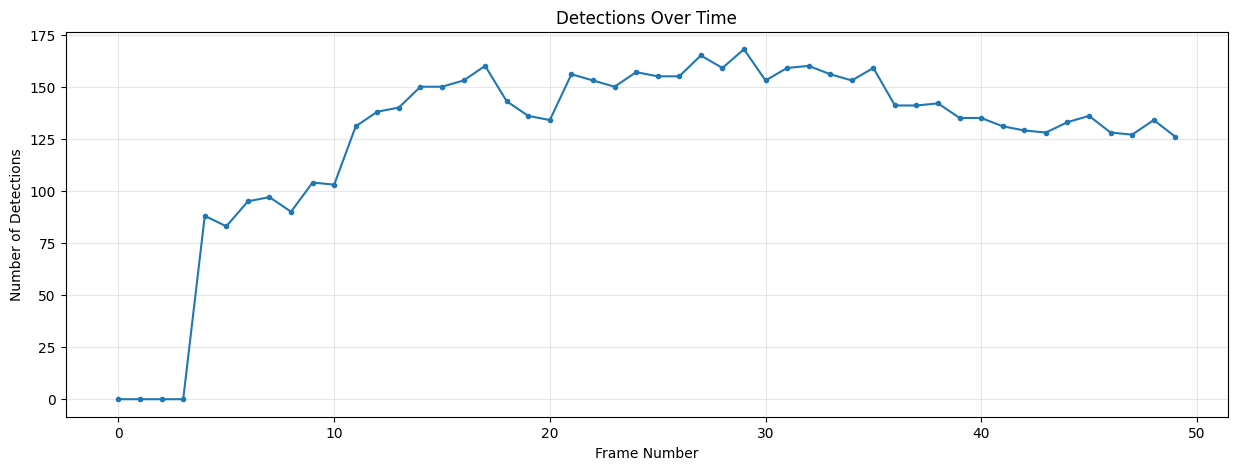

Average detections per frame: 126.38
Max detections: 168
Min detections: 0


In [9]:
detector = ObjectDetector(
    history=500,
    dist_threshold=800,
    min_area=30,
    max_area=100000,
    erode_size=(3, 3),
    dilate_size=(8, 8)
)

# Process frames
detection_counts = []

for frame in frames:
    detections = detector.detect(frame)
    detection_counts.append(len(detections))

# Plot detection counts over time
plt.figure(figsize=(15, 5))
plt.plot(detection_counts, marker='o', markersize=3)
plt.xlabel('Frame Number')
plt.ylabel('Number of Detections')
plt.title('Detections Over Time')
plt.grid(True, alpha=0.3)
plt.show()

print(f"Average detections per frame: {np.mean(detection_counts):.2f}")
print(f"Max detections: {np.max(detection_counts)}")
print(f"Min detections: {np.min(detection_counts)}")


## Parameter Tuning

Experiment with different parameters to see their effects.


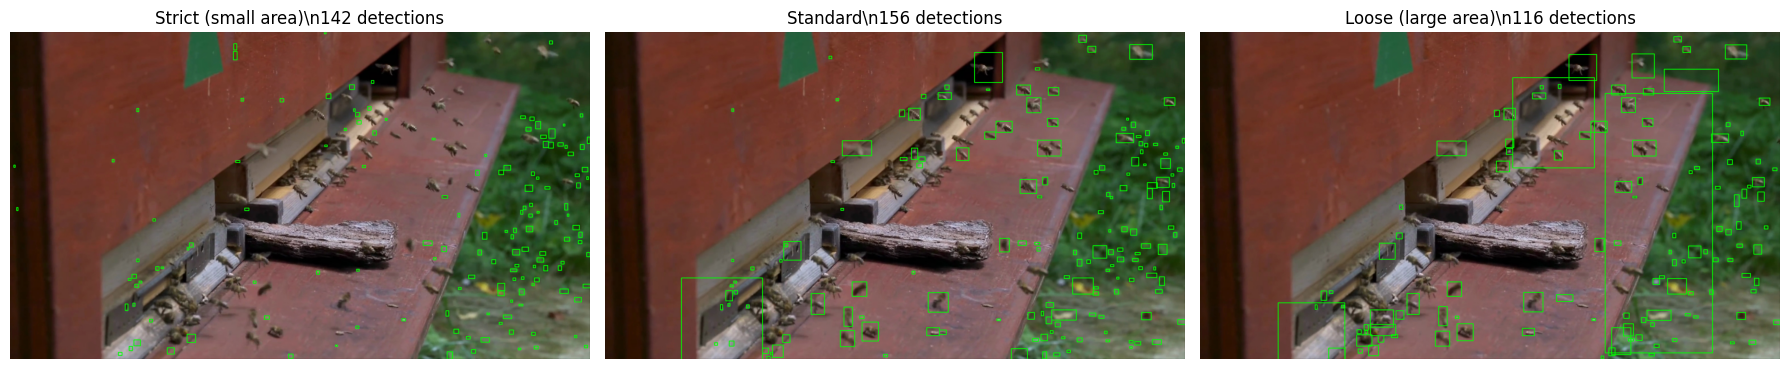

Strict (small area): 142 detections
Standard: 156 detections
Loose (large area): 116 detections


In [10]:
# Test different parameters
configs = [
    {'name': 'Strict (small area)', 'min_area': 20, 'max_area': 300, 'dist_threshold': 600},
    {'name': 'Standard', 'min_area': 30, 'max_area': 100000, 'dist_threshold': 800},
    {'name': 'Loose (large area)', 'min_area': 50, 'max_area': 100000, 'dist_threshold': 1000},
]

test_frame = frames[30]
results = []

fig, axes = plt.subplots(1, 3, figsize=(18, 6))

for idx, config in enumerate(configs):
    detector = ObjectDetector(
        history=500,
        dist_threshold=config['dist_threshold'],
        min_area=config['min_area'],
        max_area=config['max_area']
    )
    
    # Learn background
    for f in frames[:30]:
        detector.detect(f)
    
    # Detect in test frame
    detections = detector.detect(test_frame)
    
    # Visualize
    vis = test_frame.copy()
    for det in detections:
        cx, cy, w, h = det
        x, y = int(cx - w/2), int(cy - h/2)
        cv2.rectangle(vis, (x, y), (x+w, y+h), (0, 255, 0), 2)
    
    axes[idx].imshow(cv2.cvtColor(vis, cv2.COLOR_BGR2RGB))
    axes[idx].set_title(f"{config['name']}\n{len(detections)} detections")
    axes[idx].axis('off')
    
    results.append((config['name'], len(detections)))

plt.tight_layout()
plt.show()

for name, count in results:
    print(f"{name}: {count} detections")
